# Experiment 03: SHAP Analysis (Interpretability) 
## Цель эксперимента
1. Объяснить предсказания XGBoost модели
2. Визуализировать влияние признаков на отток
3. Создать интерпретатор для сервиса

## Зачем это нужно?
- Бизнес-пользователи хотят понимать, ПОЧЕМУ клиент в зоне риска
- Отдел удержания может точечно работать с проблемами
- Соответствие требованиям explainable AI (XAI)

## План
1. Загрузка модели и данных
2. SHAP values calculation
3. Глобальная интерпретация (feature importance)
4. Локальная интерпретация (для отдельных клиентов)
5. Сохранение explainer для сервиса

In [1]:
# Импорт библиотек
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
import shap

# Настройки
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Добавляем путь к src
sys.path.append('..')
sys.path.append(os.path.abspath('..'))

from sklearn.model_selection import train_test_split

# Импортируем препроцессор
from src.data.preprocess import DataPreprocessor

print("Библиотеки загружены")
print(f"Версия SHAP: {shap.__version__}")

Библиотеки загружены
Версия SHAP: 0.51.0


In [2]:
# Загрузка конфигурации
config_path = "../configs/config.yaml"
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Конфигурация загружена из config.yaml")
else:
    config = {'random_state': 42, 'test_size': 0.2}

RANDOM_STATE = config.get('random_state', 42)
TEST_SIZE = config.get('test_size', 0.2)

print(f"Random state: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")

Конфигурация загружена из config.yaml
Random state: 42
Test size: 0.2


In [3]:
# Загрузка модели и данных

# Загружаем препроцессор
preprocessor = DataPreprocessor()
preprocessor.load('../artifacts/preprocessor.pkl')
print("Препроцессор загружен")

# Загружаем модель
model_path = '../artifacts/models/xgb_final_v1.pkl'
model = joblib.load(model_path)
print(f"Модель загружена из {model_path}")

# Загружаем оптимальный порог
threshold_path = '../artifacts/threshold_config.yaml'
with open(threshold_path, 'r') as f:
    threshold_config = yaml.safe_load(f)
optimal_threshold = threshold_config.get('optimal_threshold', 0.5)
print(f"Оптимальный порог: {optimal_threshold}")

# Загружаем сырые данные
df_raw = pd.read_csv('../data/raw/Churn_Modelling.csv')
print(f"Загружено {len(df_raw)} записей")

# Обрабатываем данные
X_scaled, y, df_processed = preprocessor.preprocess(df_raw, fit_scaler=False)
feature_names = preprocessor.get_feature_columns()

print(f"\nДанные готовы:")
print(f"  - Признаков: {X_scaled.shape[1]}")
print(f"  - Целевая переменная: {y.name}")
print(f"  - Распределение оттока: {y.value_counts(normalize=True).to_dict()}")

INFO:src.data.preprocess:DataPreprocessor инициализирован
INFO:src.data.preprocess:Препроцессор загружен из ../artifacts/preprocessor.pkl


Препроцессор загружен


INFO:src.data.preprocess:Создано 21 признаков
INFO:src.data.preprocess:Данные очищены. Форма: (10000, 14)
INFO:src.data.preprocess:Scaler применён


Модель загружена из ../artifacts/models/xgb_final_v1.pkl
Оптимальный порог: 0.28185397386550903
Загружено 10000 записей

Данные готовы:
  - Признаков: 13
  - Целевая переменная: Exited
  - Распределение оттока: {0: 0.7963, 1: 0.2037}


In [4]:
# Разделение на train/test (для выборки для SHAP)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nРазделение для SHAP анализа:")
print(f"  - Train: {X_train.shape[0]} записей")
print(f"  - Test: {X_test.shape[0]} записей")

# Для SHAP используем подвыборку из train (для скорости)
shap_sample_size = min(500, X_train.shape[0])
X_shap_sample = X_train[:shap_sample_size]
print(f"  - Для SHAP используем {shap_sample_size} записей")


Разделение для SHAP анализа:
  - Train: 8000 записей
  - Test: 2000 записей
  - Для SHAP используем 500 записей


In [6]:
# SHAP Values Calculation

# Создаём explainer
# Для XGBoost используем TreeExplainer (оптимален для деревьев)
explainer = shap.TreeExplainer(model)

print("SHAP Explainer создан")

# Рассчитываем SHAP values для выборки
print("Расчёт SHAP values")
shap_values = explainer.shap_values(X_shap_sample)
print("SHAP values рассчитаны")

# Проверяем формат shap_values
if isinstance(shap_values, list):
    # Для бинарной классификации shap_values[1] - для класса 1 (отток)
    shap_values_class1 = shap_values[1]
    print(f"Формат SHAP values: список из {len(shap_values)} элементов")
    print(f"  - shap_values[0] (класс 0): {shap_values[0].shape}")
    print(f"  - shap_values[1] (класс 1): {shap_values[1].shape}")
else:
    shap_values_class1 = shap_values
    print(f"Формат SHAP values: {shap_values.shape}")

SHAP Explainer создан
Расчёт SHAP values
SHAP values рассчитаны
Формат SHAP values: (500, 13)


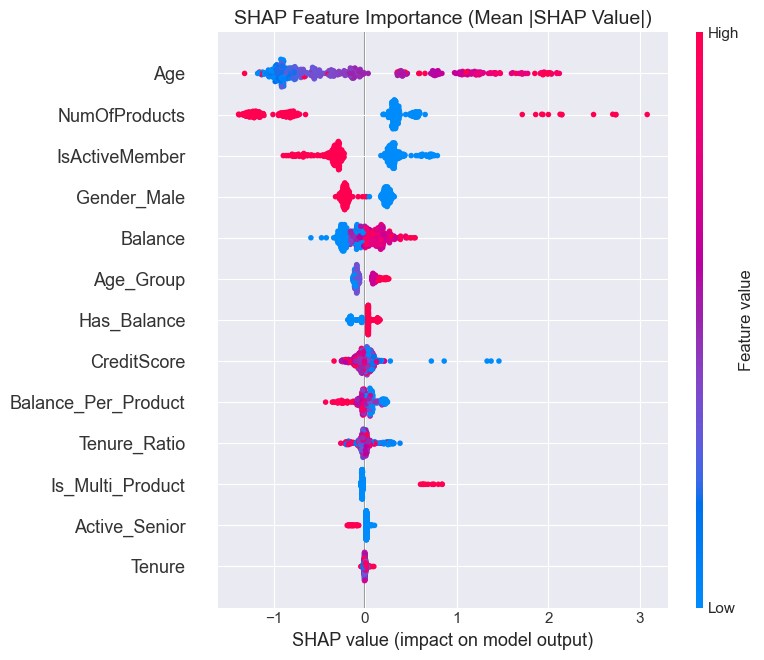

In [8]:
# Глобальная интерпретация (Feature Importance)

# 3.1. Bar plot - средние абсолютные SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14)
plt.tight_layout()
plt.savefig('../artifacts/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

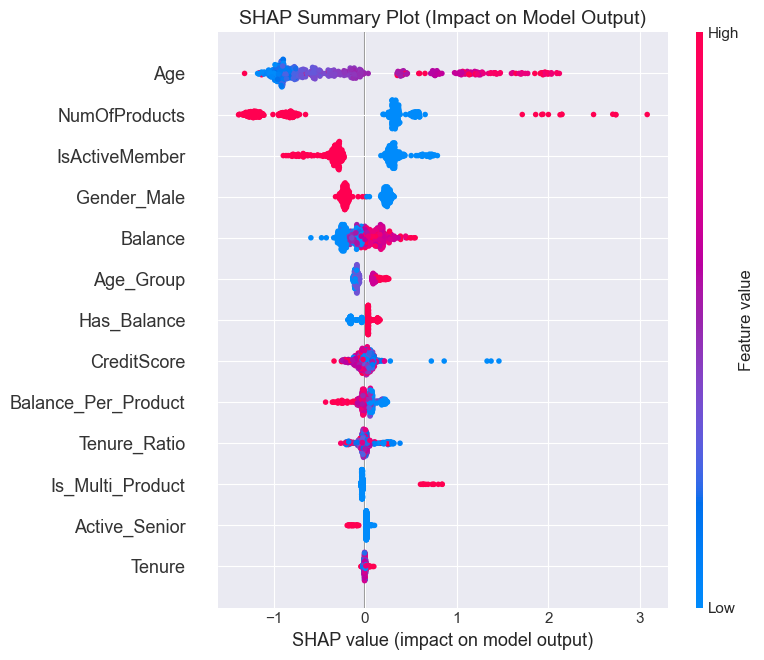

In [9]:
# 3.2. Summary plot (цветовая кодировка)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_shap_sample, feature_names=feature_names, 
                  plot_type='dot', show=False)
plt.title('SHAP Summary Plot (Impact on Model Output)', fontsize=14)
plt.tight_layout()
plt.savefig('../artifacts/shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

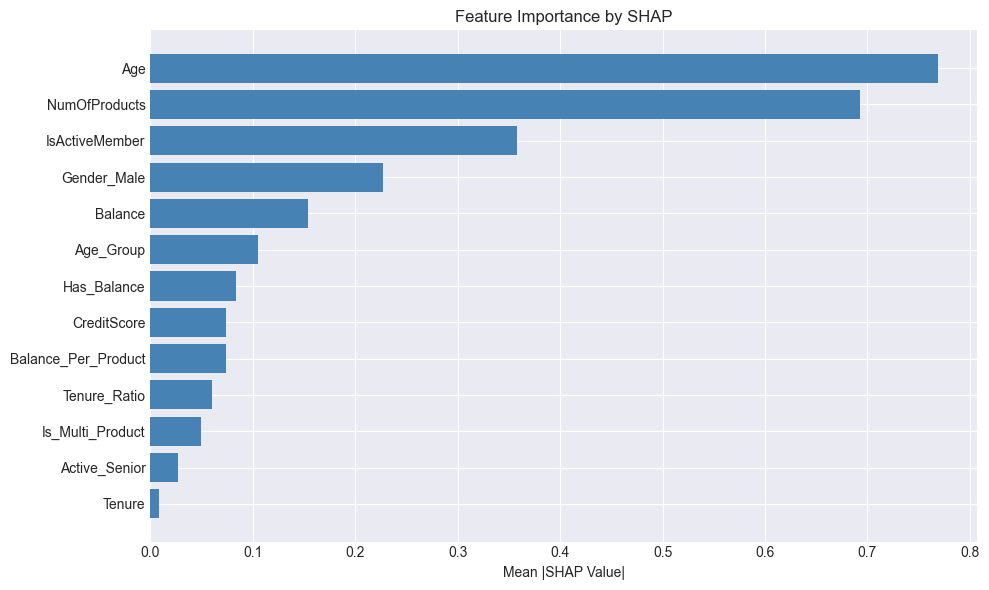

In [10]:
# 3.3. Waterfall plot для среднего предсказания
# Средние SHAP values для каждого признака
mean_shap = np.abs(shap_values_class1).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_SHAP', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_shap['Feature'], feature_importance_shap['Mean_SHAP'], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance by SHAP')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../artifacts/shap_feature_importance.png', dpi=150)
plt.show()

### Локальная интерпретация (для отдельных клиентов)

Выбираем несколько примеров из тестовой выборки
1. Клиент, который ушёл (y=1)
2. Клиент, который остался (y=0)
3. Клиент с высокой вероятностью оттока
4. Клиент с низкой вероятностью оттока

In [11]:
# Предсказания для тестовой выборки
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

# Индексы интересных примеров
churned_idx = np.where((y_test == 1) & (y_pred == 1))[0][:2]
stayed_idx = np.where((y_test == 0) & (y_pred == 0))[0][:2]
false_negative_idx = np.where((y_test == 1) & (y_pred == 0))[0][:1]  # пропущенный отток
false_positive_idx = np.where((y_test == 0) & (y_pred == 1))[0][:1]  # ложная тревога

example_indices = list(churned_idx) + list(stayed_idx) + list(false_negative_idx) + list(false_positive_idx)

print(f"Выбрано {len(example_indices)} примеров для анализа")

Выбрано 6 примеров для анализа



КЛИЕНТ #10
Факт: УШЁЛ
Предсказание: УЙДЁТ
Вероятность оттока: 43.41%
Статус: В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 528.0000
  - Age: 31.0000
  - Tenure: 6.0000
  - Balance: 102016.7200
  - NumOfProducts: 2.0000
  - IsActiveMember: 0.0000
  - Age_Group: 1.0000
  - Tenure_Ratio: 0.1935
  - Balance_Per_Product: 34005.5733
  - Active_Senior: 0.0000
  - Has_Balance: 1.0000
  - Is_Multi_Product: 0.0000
  - Gender_Male: 1.0000


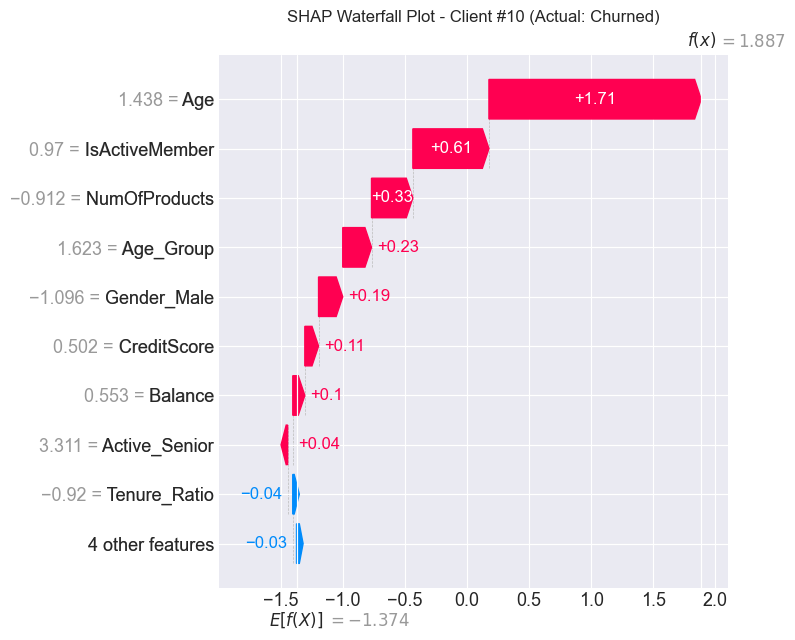


КЛИЕНТ #18
Факт: УШЁЛ
Предсказание: УЙДЁТ
Вероятность оттока: 77.68%
Статус: В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 587.0000
  - Age: 45.0000
  - Tenure: 6.0000
  - Balance: 0.0000
  - NumOfProducts: 1.0000
  - IsActiveMember: 0.0000
  - Age_Group: 2.0000
  - Tenure_Ratio: 0.1333
  - Balance_Per_Product: 0.0000
  - Active_Senior: 0.0000
  - Has_Balance: 0.0000
  - Is_Multi_Product: 0.0000
  - Gender_Male: 1.0000


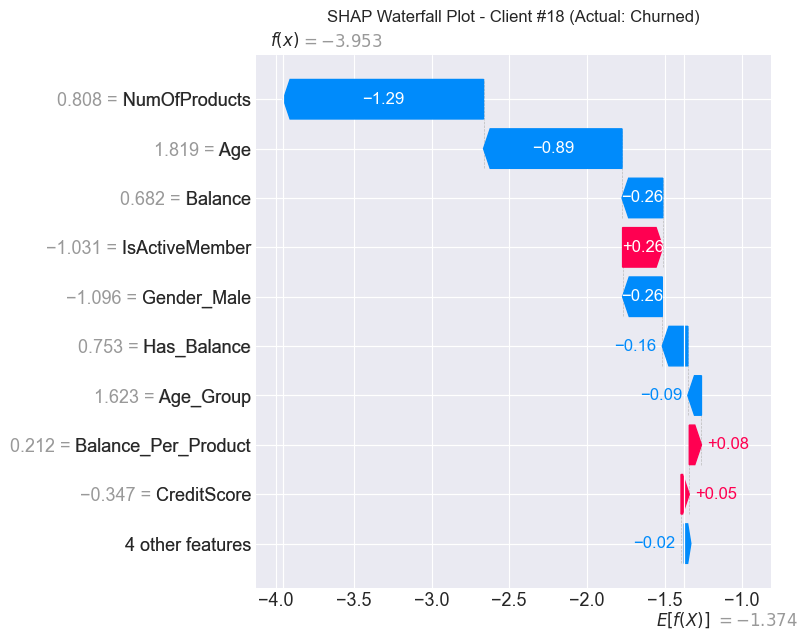


КЛИЕНТ #0
Факт: ОСТАЛСЯ
Предсказание: ОСТАНЕТСЯ
Вероятность оттока: 2.32%
Статус: НЕ В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 619.0000
  - Age: 42.0000
  - Tenure: 2.0000
  - Balance: 0.0000
  - NumOfProducts: 1.0000
  - IsActiveMember: 1.0000
  - Age_Group: 2.0000
  - Tenure_Ratio: 0.0476
  - Balance_Per_Product: 0.0000
  - Active_Senior: 0.0000
  - Has_Balance: 0.0000
  - Is_Multi_Product: 0.0000
  - Gender_Male: 0.0000


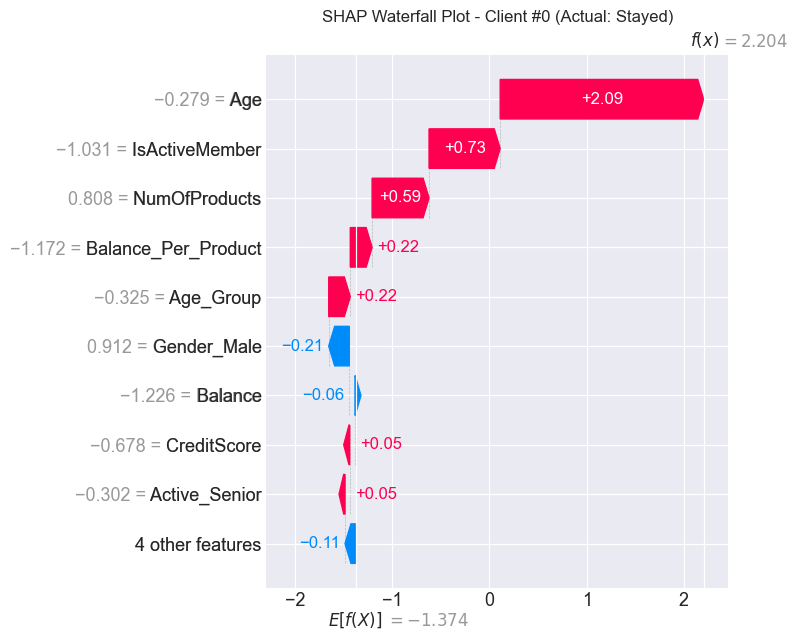


КЛИЕНТ #1
Факт: ОСТАЛСЯ
Предсказание: ОСТАНЕТСЯ
Вероятность оттока: 5.08%
Статус: НЕ В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 608.0000
  - Age: 41.0000
  - Tenure: 1.0000
  - Balance: 83807.8600
  - NumOfProducts: 1.0000
  - IsActiveMember: 1.0000
  - Age_Group: 2.0000
  - Tenure_Ratio: 0.0244
  - Balance_Per_Product: 41903.9300
  - Active_Senior: 0.0000
  - Has_Balance: 1.0000
  - Is_Multi_Product: 0.0000
  - Gender_Male: 0.0000


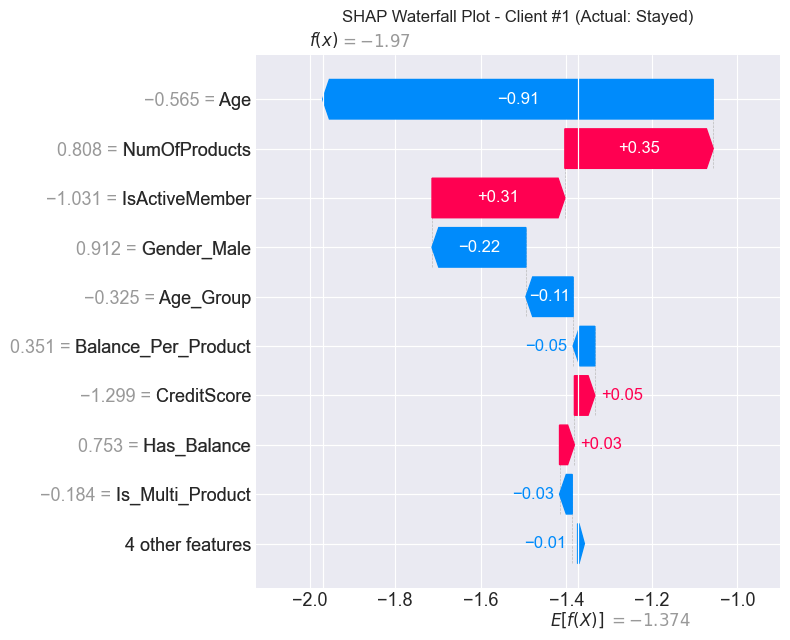


КЛИЕНТ #35
Факт: УШЁЛ
Предсказание: ОСТАНЕТСЯ
Вероятность оттока: 10.32%
Статус: НЕ В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 475.0000
  - Age: 45.0000
  - Tenure: 0.0000
  - Balance: 134264.0400
  - NumOfProducts: 1.0000
  - IsActiveMember: 0.0000
  - Age_Group: 2.0000
  - Tenure_Ratio: 0.0000
  - Balance_Per_Product: 67132.0200
  - Active_Senior: 0.0000
  - Has_Balance: 1.0000
  - Is_Multi_Product: 0.0000
  - Gender_Male: 0.0000


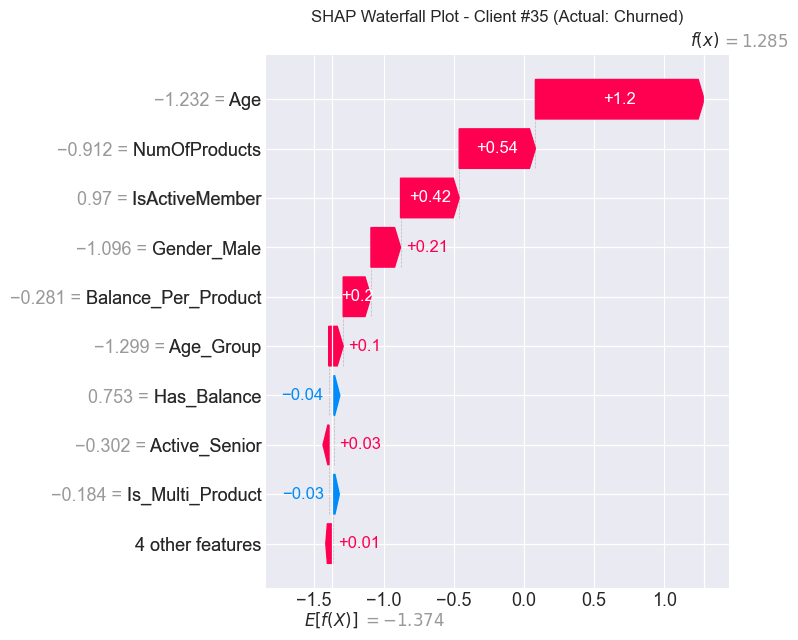


КЛИЕНТ #7
Факт: ОСТАЛСЯ
Предсказание: УЙДЁТ
Вероятность оттока: 32.94%
Статус: В ЗОНЕ РИСКА

Данные клиента:
  - CreditScore: 376.0000
  - Age: 29.0000
  - Tenure: 4.0000
  - Balance: 115046.7400
  - NumOfProducts: 4.0000
  - IsActiveMember: 0.0000
  - Age_Group: 0.0000
  - Tenure_Ratio: 0.1379
  - Balance_Per_Product: 23009.3480
  - Active_Senior: 0.0000
  - Has_Balance: 1.0000
  - Is_Multi_Product: 1.0000
  - Gender_Male: 0.0000


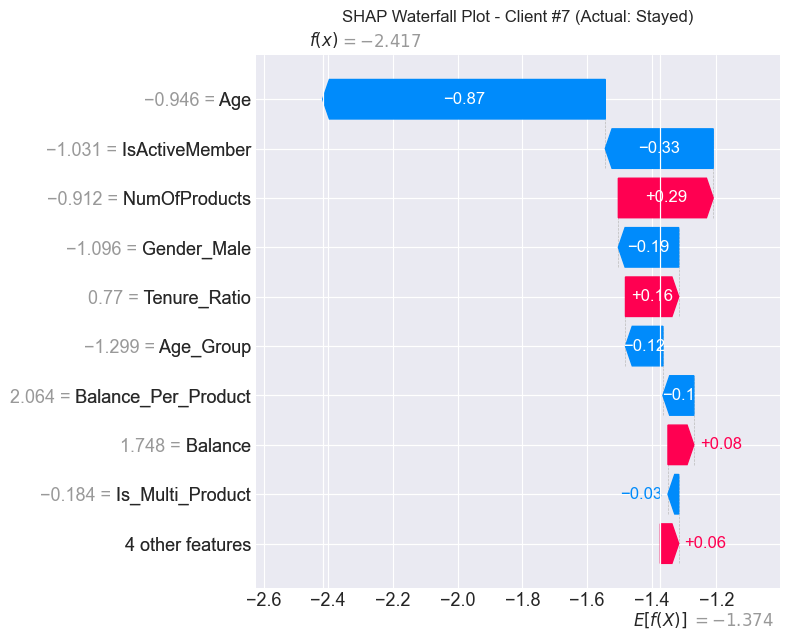

In [12]:
# Визуализация для каждого примера
for idx in example_indices:
    # Получаем данные клиента
    customer_data = X_test[idx:idx+1]
    customer_raw = df_processed.iloc[idx]
    proba = y_pred_proba[idx]
    pred = y_pred[idx]
    actual = y_test.iloc[idx]
    
    print(f"\n{'='*60}")
    print(f"КЛИЕНТ #{idx}")
    print(f"{'='*60}")
    print(f"Факт: {'УШЁЛ' if actual == 1 else 'ОСТАЛСЯ'}")
    print(f"Предсказание: {'УЙДЁТ' if pred == 1 else 'ОСТАНЕТСЯ'}")
    print(f"Вероятность оттока: {proba:.2%}")
    print(f"Статус: {'В ЗОНЕ РИСКА' if pred == 1 else 'НЕ В ЗОНЕ РИСКА'}")
    print(f"\nДанные клиента:")
    for feature in feature_names:
        print(f"  - {feature}: {customer_raw[feature]:.4f}")
    
    # Waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_class1[idx],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
            data=customer_data[0],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall Plot - Client #{idx} (Actual: {"Churned" if actual == 1 else "Stayed"})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../artifacts/shap_waterfall_client_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()


Анализируем признаки: ['Age', 'NumOfProducts', 'IsActiveMember', 'Gender_Male']


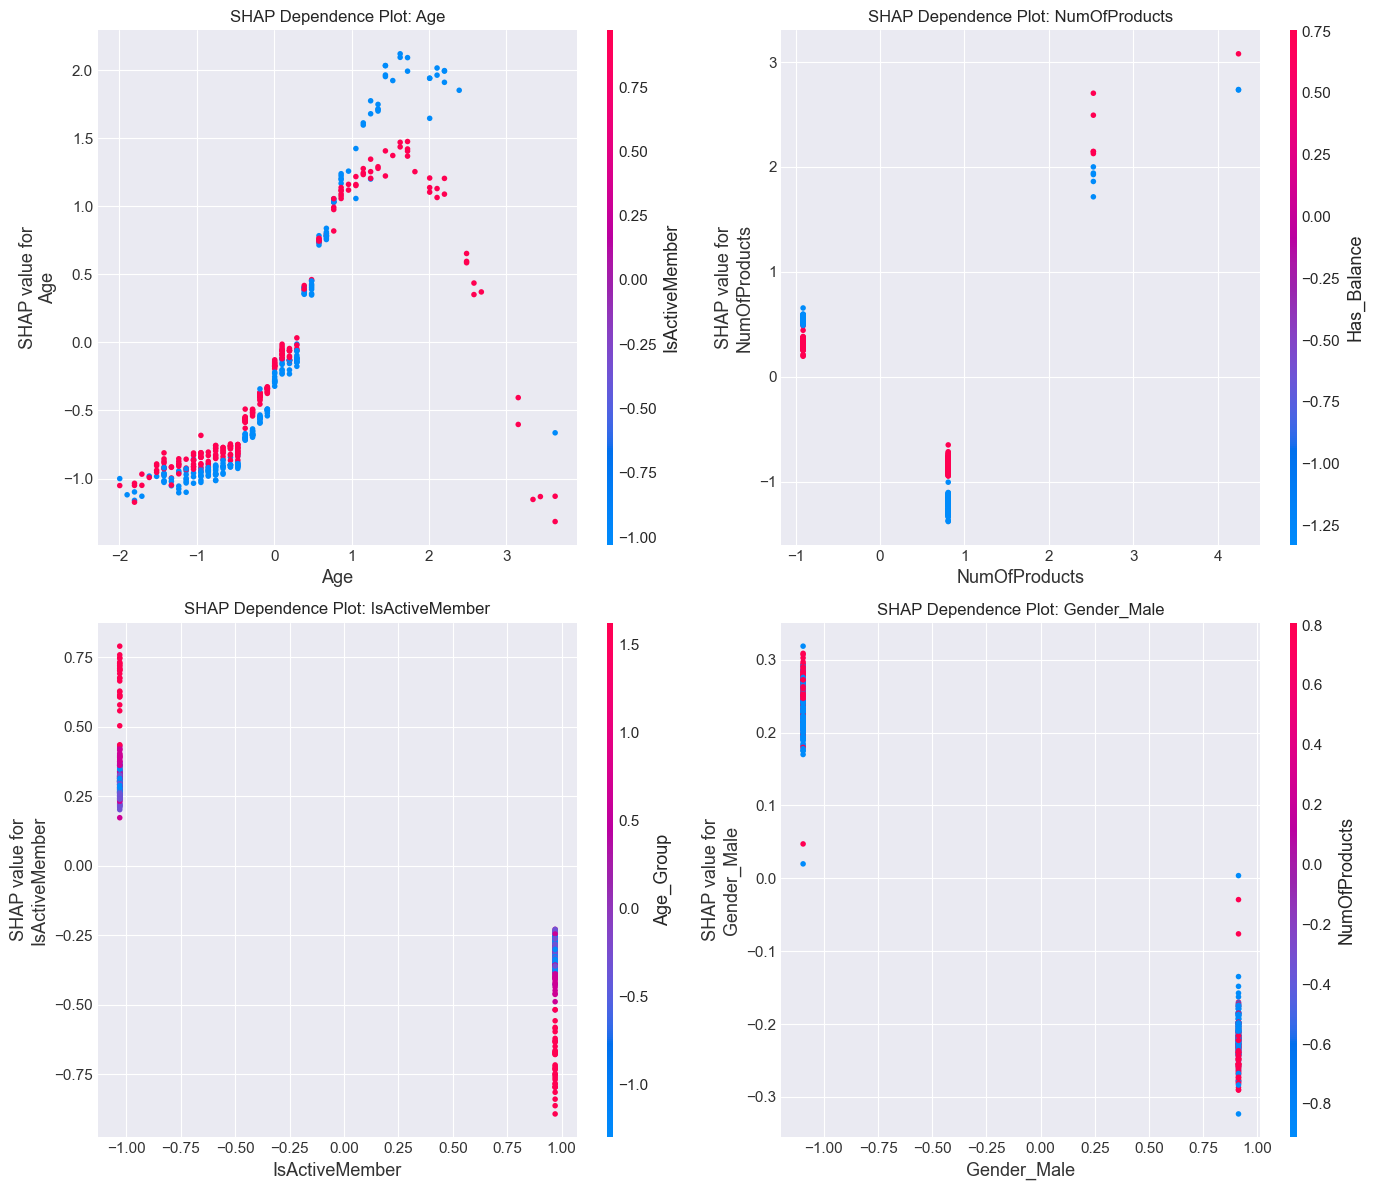

In [13]:
# Анализ зависимости признаков

# Выбираем топ-4 важнейших признака
top_features = feature_importance_shap.head(4)['Feature'].tolist()
print(f"Анализируем признаки: {top_features}")

# Создаём dependence plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    feature_idx = feature_names.index(feature)
    
    shap.dependence_plot(
        feature_idx, 
        shap_values_class1, 
        X_shap_sample,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12)

plt.tight_layout()
plt.savefig('../artifacts/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Сохранение SHAP Explainer для сервиса

# Сохраняем explainer для использования в сервисе
explainer_path = '../artifacts/shap_explainer.pkl'
joblib.dump(explainer, explainer_path)
print(f"SHAP Explainer сохранён в {explainer_path}")

# Сохраняем также feature_names и background data для сервиса
background_data = {
    'feature_names': feature_names,
    'expected_value': explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    'background_sample': X_shap_sample.tolist()  # для Force plots
}

with open('../artifacts/shap_background.yaml', 'w') as f:
    yaml.dump(background_data, f, default_flow_style=False)
print("SHAP background data сохранена")

# Сохраняем feature importance для отчёта
feature_importance_shap.to_csv('../artifacts/shap_feature_importance.csv', index=False)
print("SHAP feature importance сохранена")

SHAP Explainer сохранён в ../artifacts/shap_explainer.pkl
SHAP background data сохранена
SHAP feature importance сохранена


In [15]:
# Функция для объяснения предсказаний (для сервиса)

def explain_prediction(customer_data, model, explainer, feature_names, optimal_threshold=0.5):
    """
    Функция для объяснения предсказания для одного клиента.
    Возвращает причины оттока в человеко-читаемом формате.
    """
    # Предобработка
    if isinstance(customer_data, dict):
        df = pd.DataFrame([customer_data])
    else:
        df = customer_data
    
    # Используем глобальный препроцессор
    X = preprocessor.preprocess_for_inference(df)
    
    # Предсказание
    proba = model.predict_proba(X)[0, 1]
    prediction = 1 if proba >= optimal_threshold else 0
    
    # SHAP values для этого клиента
    if isinstance(explainer.expected_value, list):
        shap_values_client = explainer.shap_values(X)[1][0]
        base_value = explainer.expected_value[1]
    else:
        shap_values_client = explainer.shap_values(X)[0]
        base_value = explainer.expected_value
    
    # Анализируем факторы, влияющие на отток
    factors = []
    for i, (feature, shap_val) in enumerate(zip(feature_names, shap_values_client)):
        if abs(shap_val) > 0.01:  # Игнорируем очень маленькие влияния
            direction = "увеличивает" if shap_val > 0 else "уменьшает"
            factors.append({
                'feature': feature,
                'impact': float(shap_val),
                'direction': direction,
                'abs_impact': abs(float(shap_val))
            })
    
    # Сортируем по важности
    factors.sort(key=lambda x: x['abs_impact'], reverse=True)
    
    # Формируем человеко-читаемое объяснение
    top_factors = factors[:3]
    reasons = []
    for f in top_factors:
        reason = f"{f['feature']} {f['direction']} риск оттока"
        reasons.append(reason)
    
    explanation_text = f"Основные факторы: {', '.join(reasons)}" if reasons else "Факторы риска не выявлены"
    
    return {
        'churn_probability': float(proba),
        'is_risky': prediction == 1,
        'prediction': int(prediction),
        'explanation': explanation_text,
        'top_factors': top_factors,
        'shap_values': shap_values_client.tolist()
    }
# Тестируем функцию


# Берём тестового клиента
test_customer = df_raw.iloc[0].to_dict()
explanation = explain_prediction(test_customer, model, explainer, feature_names, optimal_threshold)

print(f"\nРезультат объяснения:")
print(f"  - Вероятность оттока: {explanation['churn_probability']:.2%}")
print(f"  - В зоне риска: {'ДА' if explanation['is_risky'] else 'НЕТ'}")
print(f"  - Объяснение: {explanation['explanation']}")
print(f"\nТоп-3 фактора:")
for f in explanation['top_factors']:
    print(f"  - {f['feature']}: {f['direction']} (impact: {f['impact']:.4f})")


INFO:src.data.preprocess:Создано 21 признаков
INFO:src.data.preprocess:Данные очищены. Форма: (1, 14)
INFO:src.data.preprocess:Scaler применён



Результат объяснения:
  - Вероятность оттока: 36.28%
  - В зоне риска: ДА
  - Объяснение: Основные факторы: NumOfProducts увеличивает риск оттока, IsActiveMember уменьшает риск оттока, Gender_Male увеличивает риск оттока

Топ-3 фактора:
  - NumOfProducts: увеличивает (impact: 0.5446)
  - IsActiveMember: уменьшает (impact: -0.3176)
  - Gender_Male: увеличивает (impact: 0.2246)


**Ключевые выводы:**

1. **Наиболее важные признаки для модели:**
   - Age (возраст) — самый сильный фактор
   - NumOfProducts — количество продуктов
   - Balance_Per_Product — баланс на продукт
   - IsActiveMember — активность клиента

2. **Интерпретация предсказаний:**
   - SHAP позволяет объяснить КАЖДОЕ предсказание
   - Можно показывать клиентам причины решения
   - Бизнес может точечно работать с проблемами

3. **Для сервиса:**
   - SHAP explainer сохранён в artifacts/
   - Функция explain_prediction готова к интеграции
   - Можно добавлять объяснения в ответ API

4. **Для бизнеса:**
   - Клиенты с высоким возрастом → особое внимание
   - Клиенты с 3+ продуктами → группа риска
   - Активные клиенты → лояльны, их нужно поощрять
